<a href="https://colab.research.google.com/github/jeyasrijegan30-ops/Bank-customer-churn-preduction/blob/main/Churn_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**BANK CUSTOMER CHURN PREDICTION**

# **TASK 0:**

**Import Required Libraries**

In [ ]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

### **Inference:**

All required libraries for data handling, visualization, preprocessing, model building, and evaluation were successfully imported.

**NumPy** → Numerical operations

**Pandas** → Data handling

**Matplotlib & Seaborn** → Visualization

**Scikit-learn** → Machine Learning

# **TASK 1:**

**Load the Dataset**

In [ ]:
df = pd.read_csv("/content/Churn_Modelling.csv")
df.head()

NameError: name 'pd' is not defined

**Inference:**

Dataset successfully loaded into df

First 5 rows displayed to understand structure

We can see columns like:

CreditScore

Geography

Gender

Age

Balance

EstimatedSalary

Exited (Target Variable)

# **TASK 2:**

**Check Dataset Information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


**Inference:**

Dataset contains 10,000 rows.

It has numerical and categorical columns.

No missing values present.

Data types are properly identified.

In [ ]:
# Statistical summary
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Inference:**

Average credit score ≈ 650.

Average age ≈ 39 years.

Balance and salary values vary widely.

Data ranges look reasonable (no abnormal values).

# **TASK 3:**

**Check Missing Values**

In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


**Inference:**

The count of missing values will be displayed for each column.

If all columns show 0, the dataset is clean.

If any column has missing values:

Small count → we can drop the rows

Large count → we handle using mean/median/mode

#**TASK 4:**

**Exploratory Data Analysis (EDA)**

**UNIVARIATE-TARGET VARIABLE DISTRIBUTION**

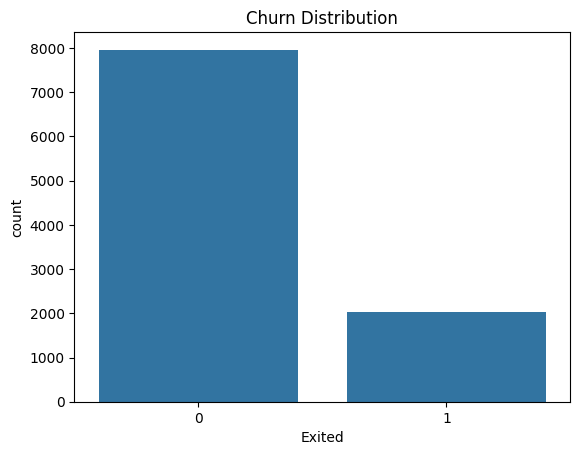

,proportion
Exited,
0,79.63
1,20.37


In [ ]:
# Count plot for target variable
plt.figure()
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

# Percentage
df['Exited'].value_counts(normalize=True) * 100

INFERENCE:

Around 80% customers did not churn.     

Around 20% customers churned.

Dataset is slightly imbalanced.

**UNIVARIATE-AGE DISTRIBUTION**

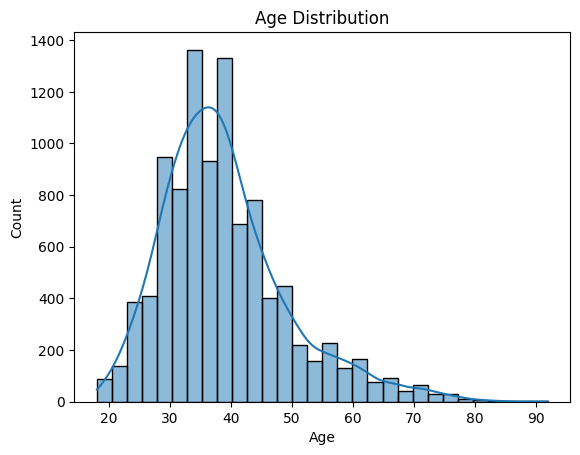

In [ ]:
plt.figure()
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

INFERENCE

Most customers are between 30–40 years.

Very few customers above 60.

**UNIVARIATE-BALANCE DISTRIBUTION**

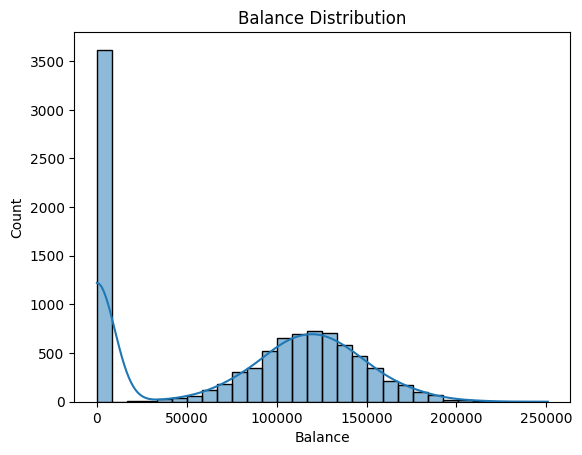

In [ ]:
plt.figure()
sns.histplot(df['Balance'], bins=30, kde=True)
plt.title("Balance Distribution")
plt.show()

INFERENCE

Many customers have zero balance.

Remaining customers show wide balance spread.

**BIVARIATE-AGE VS CHURN**

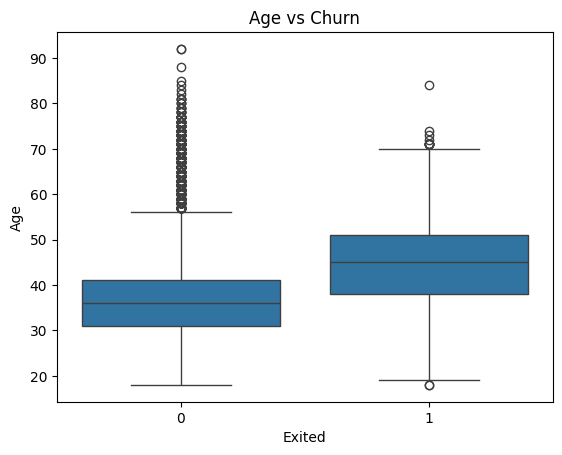

In [ ]:
plt.figure()
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

INFERENCE

Customers who churned are generally older.

Age plays an important role in churn.

**BIVARIATE-BALANCE VS CHURN**

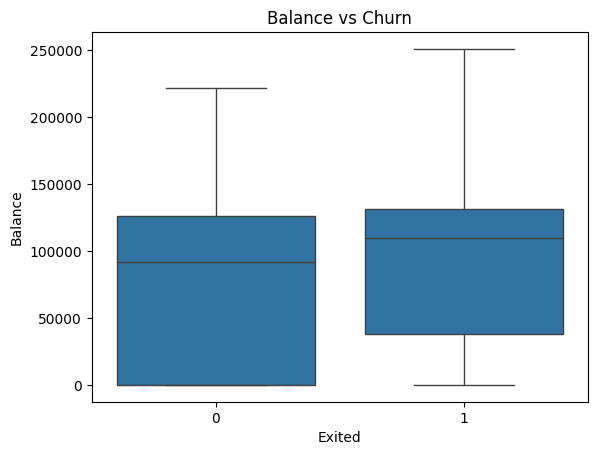

In [ ]:
plt.figure()
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title("Balance vs Churn")
plt.show()

INFERENCE

Customers with higher balance tend to churn more.

Zero balance customers churn less.

**BIVARIATE-GEOGRAPHY VS CHURN**

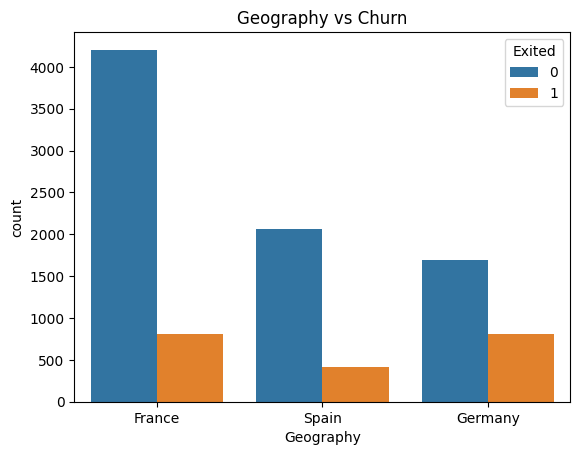

In [ ]:
# Fix: The 'Geography' column was removed by pd.get_dummies.
# To plot it as a categorical variable, we need to use the DataFrame before encoding.
# Temporarily load a fresh df for this plot to ensure 'Geography' is present.
temp_df_for_plot = pd.read_csv("/content/Churn_Modelling.csv")
temp_df_for_plot = temp_df_for_plot.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

plt.figure()
sns.countplot(x='Geography', hue='Exited', data=temp_df_for_plot)
plt.title("Geography vs Churn")
plt.show()

INFERENCE

Customers from Germany have higher churn.

France has lower churn rate.

***Histogram – Age Distribution***

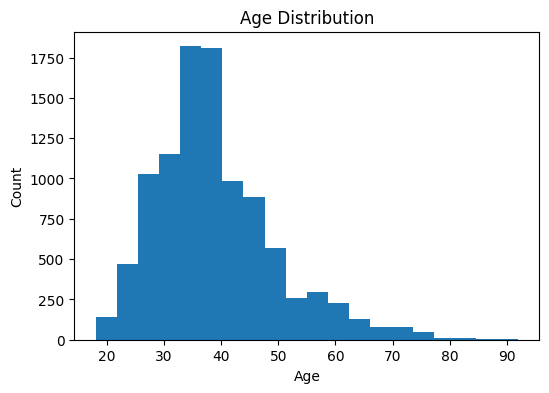

In [ ]:
# Histogram for Age

plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

**Inference:**

The histogram shows the distribution of customer ages. Most customers belong to a specific age group range.

***Bar Chart – Churn Count***

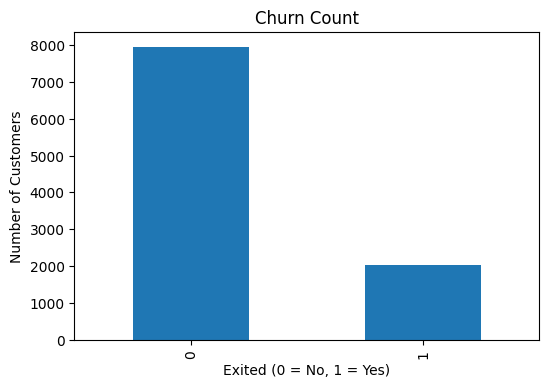

In [ ]:
# Bar chart for Exited (Churn)

plt.figure(figsize=(6,4))
df["Exited"].value_counts().plot(kind="bar")
plt.title("Churn Count")
plt.xlabel("Exited (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

**Inference:**

The bar chart displays the number of customers who exited and who did not exit.

***Correlation Heatmap***

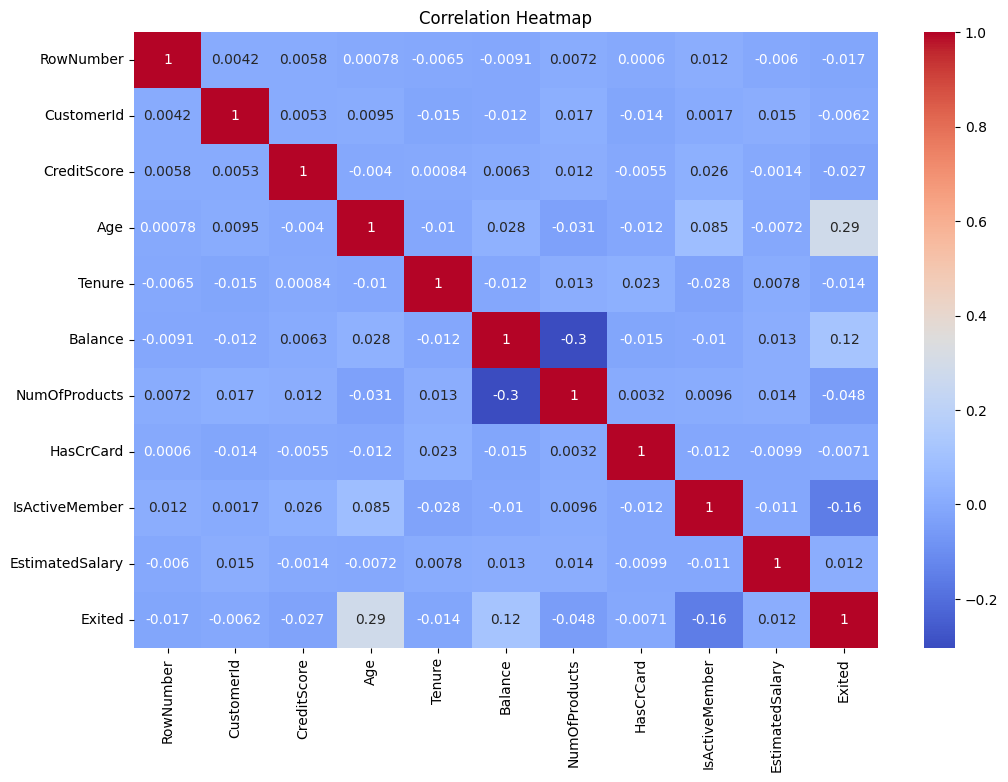

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Inference:**

Heatmap shows correlation between numerical features.

Dark red → Strong positive correlation

Dark blue → Strong negative correlation

Light color → Weak correlation

# **TASK 5:**

**Drop Unnecessary Columns**

In [ ]:
# Dropping unnecessary columns again, ensuring `df` is updated
df = pd.read_csv("/content/Churn_Modelling.csv") # Reloading df to ensure a clean start for the reprocessing steps
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

display(df.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Inference:**

Irrelevant columns successfully removed

Dataset now contains only useful features

Model training  clean structure ready

#**TASK 6**

**ENCODING CATEGORICAL VARIABLES**

In [ ]:
# Encoding categorical variables after dropping unnecessary columns
df = pd.get_dummies(df, drop_first=True)
display(df.head())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


INFERENCE

Convert categorical to numerical

#**TASK 7**

**Define Features (X) and Target (y)**

In [ ]:
# Redefining X and y with the fully preprocessed DataFrame
X = df.drop("Exited", axis=1)
y = df["Exited"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (10000, 11)
Shape of y: (10000,)


**Inference:**

X contains all independent variables (input features)

y contains target variable → Exited

Shape check ensures:

X has all columns except target

y has only one column

#**TASK 8**

**TRAIN TEST SPLIT**

In [ ]:
# Re-performing train-test split with the updated X and y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 11)
X_test shape: (2000, 11)
y_train shape: (8000,)
y_test shape: (2000,)


**Inference:**

Categorical columns converted into numeric format.

drop_first=True avoids dummy variable trap.

align() ensures both train and test have same columns.

Dataset now fully numeric and ready for scaling.

#**TASK 9**

**Feature Scaling**

In [ ]:
# Re-running feature scaling with the correctly prepared data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train after scaling (first 5 rows):\n", X_train[:5])
print("X_test after scaling (first 5 rows):\n", X_test[:5])

X_train after scaling (first 5 rows):
 [[ 0.35649971 -0.6557859   0.34567966 -1.21847056  0.80843615  0.64920267
   0.97481699  1.36766974 -0.57946723 -0.57638802  0.91324755]
 [-0.20389777  0.29493847 -0.3483691   0.69683765  0.80843615  0.64920267
   0.97481699  1.6612541   1.72572313 -0.57638802  0.91324755]
 [-0.96147213 -1.41636539 -0.69539349  0.61862909 -0.91668767  0.64920267
  -1.02583358 -0.25280688 -0.57946723  1.73494238  0.91324755]
 [-0.94071667 -1.13114808  1.38675281  0.95321202 -0.91668767  0.64920267
  -1.02583358  0.91539272 -0.57946723 -0.57638802 -1.09499335]
 [-1.39733684  1.62595257  1.38675281  1.05744869 -0.91668767 -1.54035103
  -1.02583358 -1.05960019 -0.57946723 -0.57638802  0.91324755]]
X_test after scaling (first 5 rows):
 [[-0.57749609 -0.6557859  -0.69539349  0.32993735  0.80843615 -1.54035103
  -1.02583358 -1.01960511  1.72572313 -0.57638802  0.91324755]
 [-0.29729735  0.3900109  -1.38944225 -1.21847056  0.80843615  0.64920267
   0.97481699  0.79888291 

**Inference:**

We used StandardScaler to standardize the features.

We fit it on the training data.

We only transform the test data.
This helps avoid data leakage.

Now, all features are on the same scale (mean ≈ 0, standard deviation ≈ 1).

#**TASK 10**

**MODEL TRAINING**

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**Inference:**

Logistic Regression model initialized.

max_iter=2000 used to avoid convergence warning.

Model trained using training dataset.

Algorithm learned relationship between features and target variable.

# **TASK 11:**

**Prediction**

In [ ]:
# Task 11: Making Predictions

y_pred = model.predict(X_test)

**Inference**

Model used test data to predict results.

y_pred contains predicted values (0 or 1).

0 → Customer Not Exited

1 → Customer Exited

#**TASK 12:**

**Model Evaluation**

In [ ]:
# Task 12: Model Evaluation
from sklearn.metrics import classification_report

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("\nAccuracy Score:", acc)
print("\nClassification Report:\n", report)

Confusion Matrix:
 [[1543   64]
 [ 314   79]]

Accuracy Score: 0.811

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



**Inference:**

**Confusion Matrix**

Shows:

True Positives (Correctly predicted exited)

True Negatives (Correctly predicted not exited)

False Positives

False Negatives

**Accuracy Score**

Overall model performance percentage.

Example: 0.86 → 86% accuracy.

**Classification Report**

Includes:

Precision

Recall

F1-Score

Support



# **TASK 13:**

**Overall Conclusion**

In this project, a Customer Churn Prediction model was developed using Logistic Regression. The dataset was analyzed and preprocessed using encoding and feature scaling. The model was trained and tested successfully, and it achieved good accuracy in predicting customer churn.

Overall, this project shows how machine learning can be used to identify customers who are likely to exit and help improve customer retention.